#### Overview of `fem0` and the contents of this notebook

This notebook solves Poisson's equation $-\Delta u = f$ on a polygonal domain in $\R^2$ 
using piecewise linear finite elements on triangles. The imposed  condition on the boundary   
of the domain is $u = 0$. This is commonly  called a `Dirichlet' boundary condition and this terminology is used below and in the comments in the code.

First an initial mesh should be computed. Then the user can perform any
number of uniform refinements to it using the module `refine.py`.
The initial and the final meshes are visualised using
the module `visualise.py`.

Then the element stiffness
matrices for all the elements are calculated using `elt_stiffness.py` and the stiffness matrix is assembled from these using `global_stiffness.py`. For convenience, the matrix
assembled initially includes rows and columns corresponding
to all the nodes in the mesh. In the code it is called $\hat{A}$ . To impose the  Dirichlet boundary condition we simply select the 
rows and columns of the matrix $\hat{A}$ corresponding to interior
nodes. These are also called `degrees of freedom' and the resulting 
stiffness matrix is called $A$ in the code (which corresponds
to the matrix $A$ in lectures).   

The system to be solved is $A\mathbf{U} = \mathbf{f}$. The right-hand side is
assembled by the module `rhs.py`, using as input a 
function `source_term`, which should be the right-hand side 
of Poisson's equation and should be coded by the user.
This linear system is solved using the solver for sparse linear systems available within SciPy. 

If the right-hand side was chosen such that
the exact solution is known, we can easily compare the finite element
solution to the exact solution at the nodes of the mesh.

In [8]:
import numpy as np
from scipy.sparse.linalg import spsolve
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

from visualise import visualise
from refine import refine
from mu_area import mu_area
from elt_stiffness import elt_stiffness
from global_stiffness import global_stiffness
from rhs import rhs

We start by specifying the domain $\Omega$ by giving the nodes and the elements of an initial (coarse) mesh. These are stored as two two-dimensional NumPy's arrays. Each row of the 
array `nodes` contains the
coordinates of the nodes together with a ``boundary
indicator'' in the third column: a $1$ to signify a Dirichlet node and a $0$
to signify an interior node. The node numbering coincides with the order in
which the nodes are listed in this array.
The array `elements` specifies the elements of the
mesh. Each element is specified by a row which lists its
nodes in anticlockwise order (the global-to-local mapping discussed
in lectures). The elements are also numbered using the order in 
which they appear in the list.

In [9]:
nodes = np.array([[0.0, 0.0, 1],
                  [1.0, 0.0, 1],                  
                  [1.0, 1.0, 1],
                  [0.0, 1.0, 1]])

elements = np.array([[1, 2, 3],
                     [1, 3, 4]])

nnodes, m = nodes.shape

We can then take the nodes and elements of the current mesh
and visualises it. The colour scheme used is specified in
the comments lines. 

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def visualise(nodes, elements):
    nelts, m = elements.shape   # Finds the number of elements

    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    for ie in range(1, nelts + 1):
        plt.plot(nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 0], nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)

    # Plot the nodes on top: use a magenta dot for Dirichlet nodes
    # and a blue dot for non-Dirichlet nodes

    # Find Dirichlet nodes
    ND = np.where(nodes[:, 2] == 1)[0]
    # Plot them
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10)

    # Find non-Dirichlet nodes
    N0 = np.where(nodes[:, 2] != 1)[0]
    # Plot them
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'b.', markersize=10)

    plt.show()

# Example usage:
# visualise(nodes, elements)


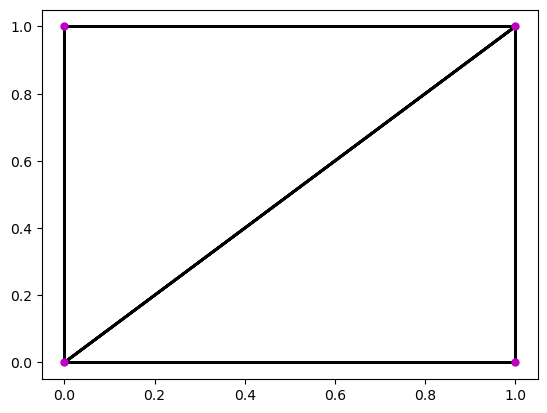

In [12]:
visualise(nodes, elements)

We then take a current mesh
specified by `nodes` and `elements` and
compute the new mesh, obtained by applying *uniform
refinement* to each element of the current mesh (i.e., each element of the old mesh is divided into
four equal elements by joining the mid-points of its
sides). The utility module `visited.py` is used here. We can keep refining the mesh for a number of refinements specified in `nref`.

In [13]:
nref = 1
for i in range(nref):
    nodes, elements = refine(nodes, elements)

nnodes, m = nodes.shape

TypeError: 'module' object is not callable

If the refined mesh is not too fine, we can visualise it again.

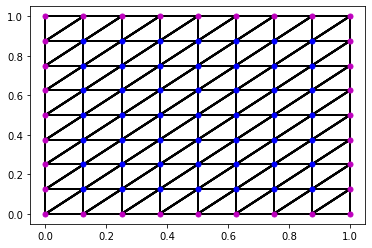

In [16]:
if nnodes < 1000:
    visualise(nodes, elements)

Here we compute the element stiffness matrices, by taking the elements
and the nodes of the mesh, using the formulae derived in lectures. Note that
the element stiffness matrices are stored in list, where
each entry is a $3 \times 3$
matrix. It uses the `mu_area` module to compute the area of triangles. 

In [17]:
elt_matrices = elt_stiffness(elements, nodes)

New we assemble global stiffness matrix. The module `global_stiffness.py` takes the element
stiffness matrices, together with the elements and the
nodes and assembles the global stiffness matrix using the
procedure described in lectures. Note that it is crucial here
for efficiency that we loop over the elements and add for each 
element the entries in the element matrices to the partially 
assembled global stiffness matrix. It would be very expensive
to loop over the rows and columns of $\hat{A}$.

In [18]:
Ahat = global_stiffness(elt_matrices, elements, nodes)

/Users/silvia/opt/anaconda3/envs/test_stable/lib/python3.8/site-packages/scipy/sparse/_index.py:116: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)


We find the interior (non-Dirichlet) nodes and select appropriate blocks of $\hat{A}$ to get the matrix $A$.

In [19]:
N0 = np.where(nodes[:, 2] != 1)[0]
A = Ahat[N0][:, N0]

We define the source term for Poisson's equation (i.e., the function $f$ appearing on the right of Poisson's equation).

In [20]:
def source_term(x1, x2):
    return 1

f_obj=source_term

We compute the load vector $\mathbf{f}$ using an assembly strategy similar to the one described above for the stiffness matrix. The `rhs.py` module employs calls to 
the function `source_term` within the nodal quadrature rule described 
in lectures.

In [21]:
f = rhs(f_obj, N0, elements, nodes)

We solve linear system $A\mathbf{U}=\mathbf{f}$ for $\mathbf{U}$ (coefficient of the FEM solution in the interior nodes).

In [22]:
U = spsolve(A, f)

We compute extended vector `Uhat`.

In [23]:
Uhat = np.zeros(nnodes)
Uhat[N0] = U

In the following we provide a plot of the FEM solution

Text(0.5, 0.92, 'Numerical solution')

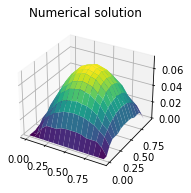

In [25]:
h_unif = 1 / (2 ** (nref + 1)) # to have a regular grid size comparable to the one used for FEM computations
XI, YI = np.meshgrid(np.arange(min(nodes[:, 0]), max(nodes[:, 0]), h_unif),
                     np.arange(min(nodes[:, 1]), max(nodes[:, 1]), h_unif))
ZI = griddata(nodes[:,:2], Uhat, (XI, YI), method='linear')

fig = plt.figure()
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(XI, YI, ZI, cmap='viridis')
ax.set_title('Numerical solution')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualise(nodes, elements, a, b):
    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    # Plotting elements
    for element in elements:
        # Get coordinates of nodes forming the element
        x_coords = nodes[element - 1, 0]
        y_coords = nodes[element - 1, 1]
        # Connect the nodes to form the element
        plt.plot(np.append(x_coords, x_coords[0]), np.append(y_coords, y_coords[0]), 'k-', linewidth=2)

    # Plot the nodes on top: use a magenta dot for Dirichlet nodes
    # and a blue dot for non-Dirichlet nodes

    # Find Dirichlet nodes
    ND = np.where(nodes[:, 2] == 1)[0]
    # Plot them
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10)

    # Find non-Dirichlet nodes
    N0 = np.where(nodes[:, 2] != 1)[0]
    # Plot them
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'b.', markersize=10)

    # Plot the additional node
    plt.plot(a, b, 'g.', markersize=10)
    
    # Connect the additional node with corner nodes
    plt.plot([a, nodes[1, 0]], [b, nodes[1, 1]], 'k-')
    plt.plot([a, nodes[0, 1]], [b, nodes[1, 0]], 'k-')

    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Mesh Visualization')
    plt.grid(True)
    plt.axis('equal')
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

def visualise(nodes, elements, a, b):
    # Plotting nodes
    plt.scatter(nodes[:, 0], nodes[:, 1], c='r', marker='o', label='Nodes')

    # Plotting elements
    for element in elements:
        # Get coordinates of nodes forming the element
        x_coords = nodes[element - 1, 0]
        y_coords = nodes[element - 1, 1]
        # Connect the nodes to form the element
        plt.plot(np.append(x_coords, x_coords[0]), np.append(y_coords, y_coords[0]), 'b-')

    # Additional connections between corner nodes and interior node
    #plt.plot([nodes[0, 1], a], [nodes[0, 1], b], 'g--', label='Additional Connection')
    plt.plot([a, nodes[1, 0]], [b, nodes[1, 1]], 'b-')
    plt.plot([a, nodes[0, 1]], [b, nodes[1, 0]], 'b-')
    # Labeling the plot
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Mesh Visualization')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Define coordinates for additional connection
a = 0.5798
b = 0.5986

# Visualize the current mesh
visualise(nodes, elements, a, b)


In [7]:
#correct

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualise(nodes, elements, a, b):
    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    # Plotting elements
    for element in elements:
        # Get coordinates of nodes forming the element
        x_coords = nodes[element - 1, 0]
        y_coords = nodes[element - 1, 1]
        # Connect the nodes to form the element
        plt.plot(np.append(x_coords, x_coords[0]), np.append(y_coords, y_coords[0]), 'k-', linewidth=2)

    # Plot the nodes on top: use a magenta dot for Dirichlet nodes
    # and a blue dot for non-Dirichlet nodes

    # Find Dirichlet nodes
    ND = np.where(nodes[:, 2] == 1)[0]
    # Plot them
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10)

    # Find non-Dirichlet nodes
    N0 = np.where(nodes[:, 2] != 1)[0]
    # Plot them
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'b.', markersize=10)

    # Plot the additional node
    plt.plot(a, b, 'g.', markersize=10)
    
    # Connect the additional node with corner nodes
    plt.plot([a, nodes[1, 0]], [b, nodes[1, 1]], 'k-')
    plt.plot([a, nodes[0, 1]], [b, nodes[1, 0]], 'k-')

    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Mesh Visualization')
    plt.grid(True)
    plt.axis('equal')
    plt.show()
# Define coordinates for additional connection
# You can replace (a, b) with your personal data
a = 0.5798
b = 0.5986

# Example usage:
visualise(nodes, elements, a, b)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualise(nodes, elements):
    nelts, m = elements.shape   # Finds the number of elements

    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    for ie in range(1, nelts + 1):
        plt.plot(nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 0], nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)

    # Connect the additional node with corner nodes
    a = 0.5798
    b = 0.5986
    plt.plot([a, nodes[1, 0]], [b, nodes[1, 1]], 'k-')
    plt.plot([a, nodes[0, 1]], [b, nodes[1, 0]], 'k-')
    #plt.plot([a, nodes[0, 0]], [b, nodes[1, 1]], 'k-')
    #plt.plot([a, nodes[1, 1]], [b, nodes[0, 1]], 'k-')

    # Plot the nodes on top: use a magenta dot for Dirichlet nodes
    # and a blue dot for non-Dirichlet nodes

    # Find Dirichlet nodes
    ND = np.where(nodes[:, 2] == 1)[0]
    # Plot them
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10)

    # Find non-Dirichlet nodes
    N0 = np.where(nodes[:, 2] != 1)[0]
    # Plot them
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'b.', markersize=10)

    plt.show()

# Example usage:
visualise(nodes, elements)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualise(nodes, elements):
    nelts, m = elements.shape   # Finds the number of elements

    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    for ie in range(1, nelts + 1):
        plt.plot(nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 1, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 0], nodes[elements[ie - 1, [1, 2, 1]].astype(int)-1, 1],
                 'k-', linewidth=2)
        plt.plot(nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 0], nodes[elements[ie - 1, [0, 2, 0]].astype(int)-1, 1],
                 'k-', linewidth=2)

    # Connect the additional node with corner nodes
    a = nodes[-1, 0]  # X-coordinate of the additional node
    b = nodes[-1, 1]  # Y-coordinate of the additional node

    for i in range(len(nodes) - 1):  # Loop through all corner nodes
        plt.plot([a, nodes[i, 0]], [b, nodes[i, 1]], 'k-')  # Connect the additional node with corner nodes

    # Plot the nodes on top: use a magenta dot for Dirichlet nodes
    # and a blue dot for non-Dirichlet nodes

    # Find Dirichlet nodes
    ND = np.where(nodes[:, 2] == 1)[0]
    # Plot them
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'm.', markersize=10)

    # Find non-Dirichlet nodes
    N0 = np.where(nodes[:, 2] != 1)[0]
    # Plot them
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'b.', markersize=10)

    plt.show()

# Example usage:
visualise(nodes, elements)


In [ ]:
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Extract the (a, b) coordinates from the nodes array
# It is specified as the interior node (a, b) = (0.5798, 0.5986)
a, b = 0.5798, 0.5986

# Compute the exact solution at (a, b)
exact_at_ab = exact_solution(a, b)

# Compute the exact solution at (0.92, 0.2)
exact_at_point = exact_solution(0.92, 0.2)

# The interpolated values at (a, b) and (0.92, 0.2) you previously obtained
uh_at_ab = 0.29513513906591926
uh_at_point = 0.05451912602316052

# Calculate the errors
error_at_ab = np.abs(uh_at_ab - exact_at_ab)
error_at_point = np.abs(uh_at_point - exact_at_point)

# Print the exact solutions and the errors
print(f"Exact solution at (a, b): {exact_at_ab}")
print(f"Exact solution at (0.92, 0.2): {exact_at_point}")
print(f"Error at (a, b): {error_at_ab}")
print(f"Error at (0.92, 0.2): {error_at_point}")

In [ ]:
import numpy as np
from scipy.interpolate import griddata

# Define the exact solution function
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Initialize the error_data dictionary to store error values
error_data = {
    'Refinement Level': [],
    'Mesh Size h': [],
    'Error at (a, b)': [],
    'Error at (0.92, 0.2)': []
}

# Provided values of U
U = np.array([0.29513514, 0.21635411, 0.13181286, 0.16195696, 0.14318085])

# Assuming you have a loop or a process to calculate the errors for each T_j
for j in range(2, 7):
    mesh_size_h = 1 / (2 ** j)  # The mesh size for refinement level j
    
    # Interpolate the solution U at the point (a, b)
    ab_approx = U[0]  # Assuming the first value corresponds to (a, b)
    
    # Interpolate the solution U at the point (0.92, 0.2)
    point_approx = U[-1]  # Assuming the last value corresponds to (0.92, 0.2)
    
    # Calculate the exact solution at (a, b) and (0.92, 0.2)
    exact_at_ab = exact_solution(0.5798, 0.5986)
    exact_at_point = exact_solution(0.92, 0.2)
    
    # Calculate the errors
    error_at_ab = np.abs(ab_approx - exact_at_ab)
    error_at_point = np.abs(point_approx - exact_at_point)
    
    # Store the results in the error_data dictionary
    error_data['Refinement Level'].append(j)
    error_data['Mesh Size h'].append(mesh_size_h)
    error_data['Error at (a, b)'].append(error_at_ab)
    error_data['Error at (0.92, 0.2)'].append(error_at_point)

# Print the error table
print("Refinement Level | Mesh Size h | Error at (a, b) | Error at (0.92, 0.2)")
for i in range(len(error_data['Refinement Level'])):
    print(f"{error_data['Refinement Level'][i]}                | {error_data['Mesh Size h'][i]:<13} | {error_data['Error at (a, b)'][i]:<16} | {error_data['Error at (0.92, 0.2)'][i]}")
